In [1]:
from qiskit import *

In [2]:
def sum_by_const(c: int, n: int):
    """
    sum a constant c to an n-bit quantum register. The result is stored in the same register.
    """
    quantum_circuit = QuantumCircuit(n)
    for i in range(n):
        if (c >> i) & 1:
            quantum_circuit.x(i)

    return quantum_circuit

In [43]:
def carry_with_const(c: int, n: int):
    """
    computes the carry of the sum of a constant c to an n-bit quantum register.
    result outbut is a single qubit.
    for the circuit construction, we use n-1 dirty ancilla qubits in an arbitrary state |g>, that are returned to the same state at the end of the computation.
    """
    reg_a = QuantumRegister(n, name='a')
    reg_g = QuantumRegister(n-1, name='g')
    reg_carry = QuantumRegister(1, name='carry')
    quantum_circuit = QuantumCircuit(reg_a, reg_g, reg_carry)

    quantum_circuit.cx(reg_g[n-2], reg_carry[0])

    for i in range(n - 2, -1, -1):
        if (c >> (i+1)) & 1:
            quantum_circuit.cx(reg_a[i+1], reg_g[i])
            quantum_circuit.x(reg_a[i+1])
        if i == 0: continue
        quantum_circuit.ccx(reg_g[i-1], reg_a[i+1], reg_g[i])

    if(c&1):
        quantum_circuit.ccx(reg_a[0], reg_a[1], reg_g[0])

    for i in range(n - 2):
        quantum_circuit.ccx(reg_g[i], reg_a[i+2], reg_g[i+1])

    quantum_circuit.cx(reg_g[n-2], reg_carry[0])

    for i in range(n - 3, -1, -1):
        quantum_circuit.ccx(reg_g[i], reg_a[i+2], reg_g[i+1])

    if(c&1):
        quantum_circuit.ccx(reg_a[0], reg_a[1], reg_g[0])

    for i in range(n - 1):
            if i != 0:
                quantum_circuit.ccx(reg_g[i-1], reg_a[i+1], reg_g[i])
            if (c >> (i+1)) & 1:
                quantum_circuit.x(reg_a[i+1])
                quantum_circuit.cx(reg_a[i+1], reg_g[i])
                
    return quantum_circuit

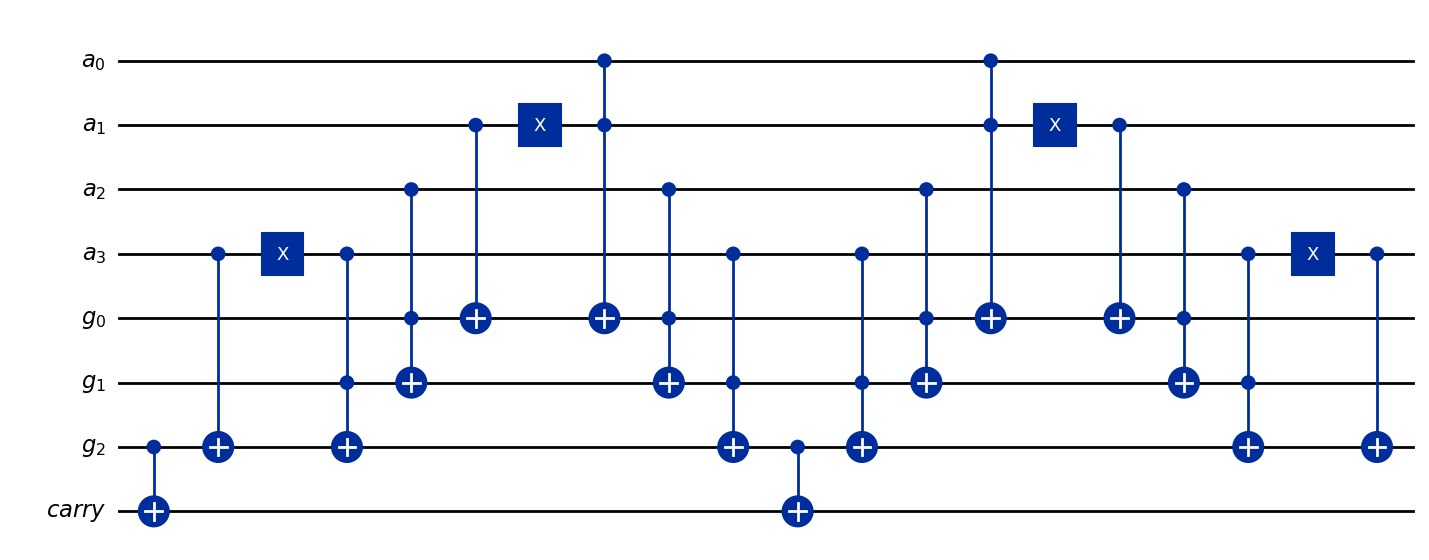

In [48]:
carry_with_const(11, 4).draw('mpl')

In [76]:
from qiskit.quantum_info import Statevector
qc = QuantumCircuit(8)
qc.x(0)
qc.x(1)
qc.x(2)
qc.x(3)
qc.append(carry_with_const(11, 4), range(8))
psi = Statevector(qc)
psi.draw("latex")

<IPython.core.display.Latex object>